✅ 라이브러리 설치 및 설정 완료

🚀 [Step 1] 원본 데이터 로드 및 확인

--- [이용정보 데이터 예시 (상위 3개)] ---


,자치구,대여소명,기준년월,대여건수,반납건수
0,마포구,108. 서교동 사거리,202501,670,786
1,양천구,729. 서부식자재마트 건너편,202501,961,939
2,양천구,731. 서울시 도로환경관리센터,202501,1671,1722



--- [마스터 정보 데이터 예시 (상위 3개)] ---


,대여소_ID,주소1,주소2,위도,경도
0,ST-999,서울특별시 양천구 목동서로 280,목동아파트 8단지 상가동,0.00000,0.000000
1,ST-998,서울특별시 양천구 목동서로 130,목동아파트 4단지 상가동,0.00000,0.000000
2,ST-997,서울특별시 양천구 목동중앙로 49,목동3단지 시내버스정류장,37.53439,126.869598



🚀 [Step 2] 데이터 정제 및 병합 (Merge)
✅ 병합 완료! 'seoul_bike_final_data.csv' 파일로 저장했습니다.
   - 총 데이터 개수: 3862건


,자치구,대여소명,기준년월,대여건수,반납건수,대여소명_clean,대여소_ID,주소1,주소2,위도,경도
0,양천구,729. 서부식자재마트 건너편,202501,961,939,서부식자재마트 건너편,ST-1000,서울특별시 양천구 신정동 236,서부식자재마트 건너편,37.510380,126.866798
1,양천구,731. 서울시 도로환경관리센터,202501,1671,1722,서울시 도로환경관리센터,ST-1002,서울특별시 양천구 목동동로 316-6,서울시 도로환경관리센터,37.529900,126.876541
2,양천구,733. 신정이펜하우스314동,202501,299,154,신정이펜하우스314동,ST-1004,서울특별시 양천구 신정이펜1로50,신정이펜하우스314동,37.514099,126.831001



🚀 [Step 3] 피처 엔지니어링 (변수 생성)
✅ 파생 변수 생성 완료: month, district_code, cluster, is_summer

🚀 [Step 4] XGBoost 모델 학습 시작
📊 [최종 모델 성능]
 - R2 Score (정확도): 0.8923
 - MAE (평균 오차): 207.0건

🚀 [Step 5] 시각화 차트 6종 생성


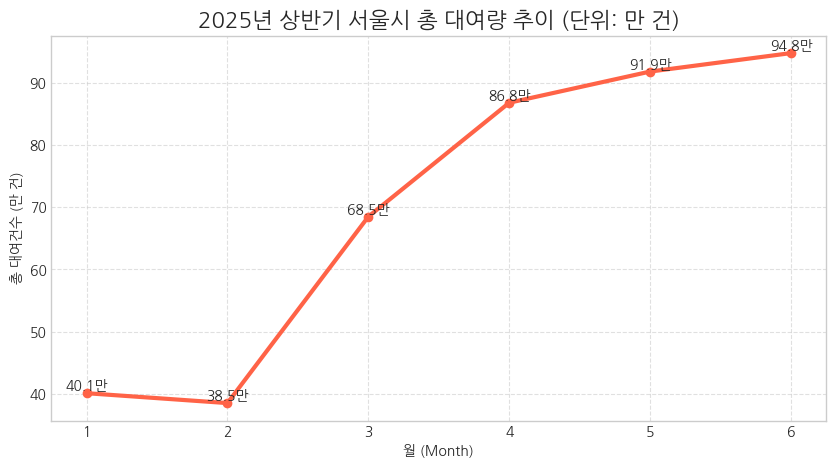

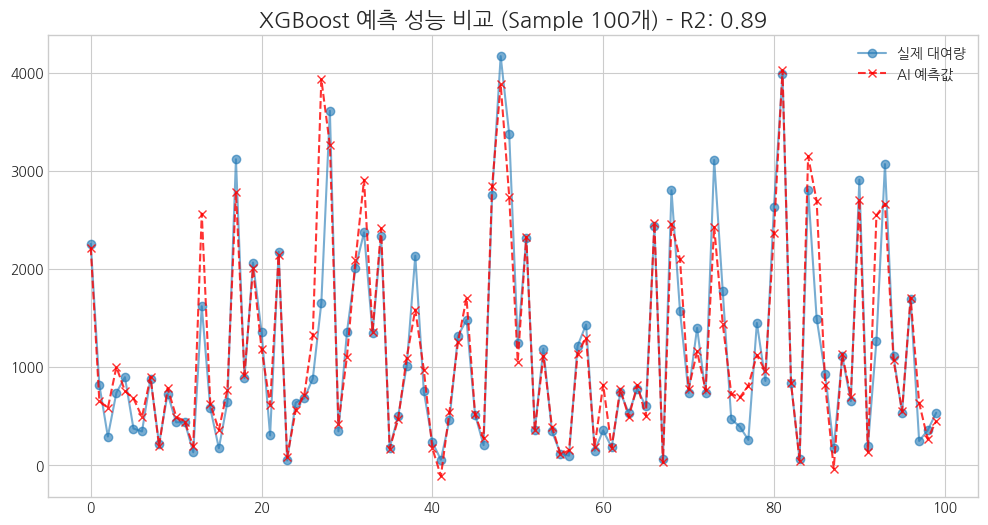

/tmp/ipython-input-1194715489.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


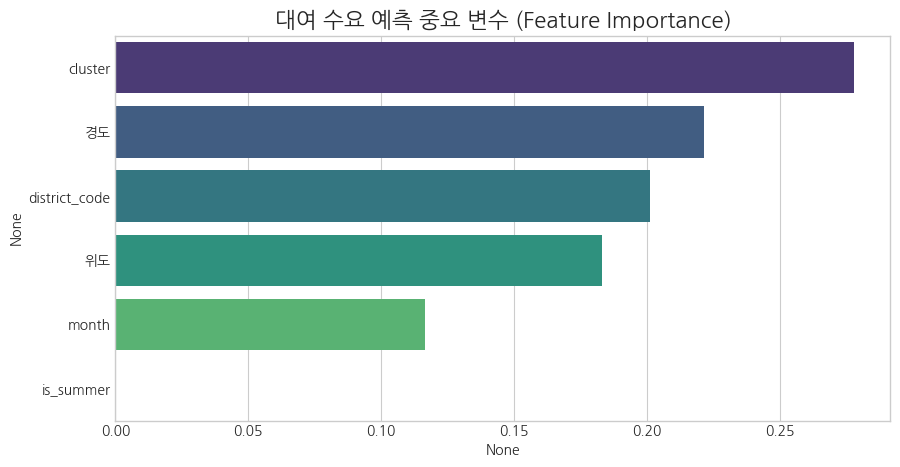

/tmp/ipython-input-1194715489.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='대여건수', palette='Set3')


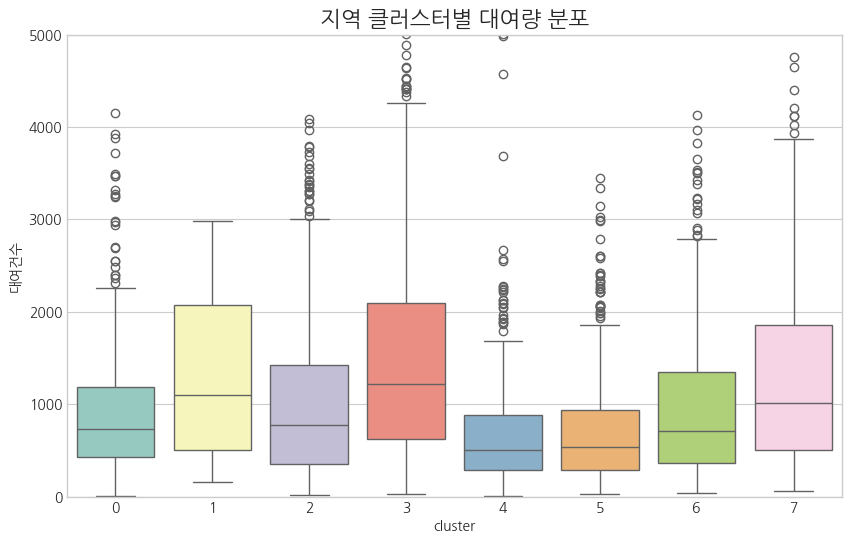

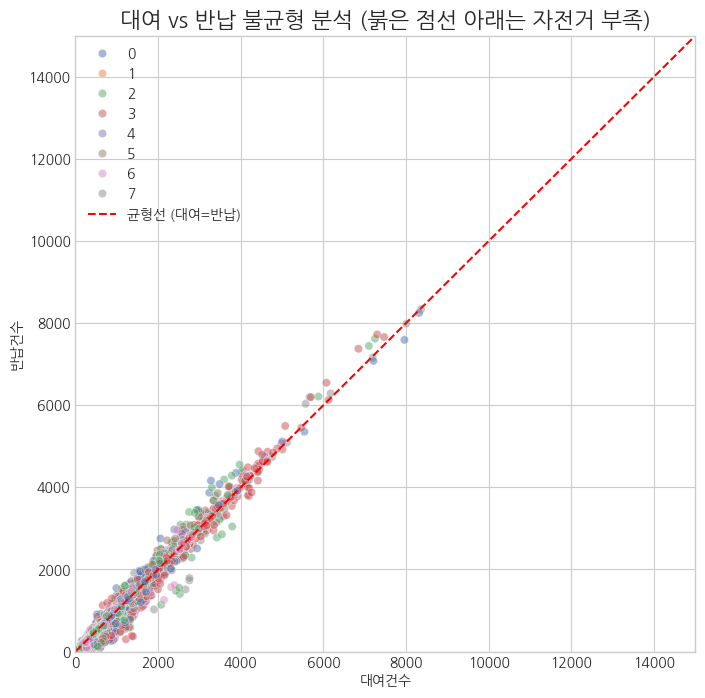


🗺️ [지도] Top 50 핫플레이스 생성 중...


In [17]:
# ==========================================
# 1. 🛠️ 환경 설정 및 라이브러리
# ==========================================
# 한글 폰트 깨짐 방지 (설치 후 자동 적용)
!pip install -q koreanize-matplotlib
import koreanize_matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from google.colab import files # 파일 다운로드용

# 머신러닝 관련 라이브러리
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

# 마이너스 기호 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 설치 및 설정 완료")


# ==========================================
# 2. 📂 데이터 로드 및 기초 확인 (Data Inspection)
# ==========================================
print("\n🚀 [Step 1] 원본 데이터 로드 및 확인")

file_usage = '서울특별시 공공자전거 대여소별 이용정보(월별)_25.1-6.csv'
file_master = '서울시 따릉이대여소 마스터 정보.csv'

def load_csv_safe(filename):
    try: return pd.read_csv(filename, encoding='cp949')
    except: return pd.read_csv(filename, encoding='utf-8')

df_usage = load_csv_safe(file_usage)
df_master = load_csv_safe(file_master)

# [보고서용] 데이터 생김새 확인 (head 출력)
print("\n--- [이용정보 데이터 예시 (상위 3개)] ---")
display(df_usage.head(3))

print("\n--- [마스터 정보 데이터 예시 (상위 3개)] ---")
display(df_master.head(3))


# ==========================================
# 3. 🧹 데이터 전처리, 병합 및 저장 (ETL)
# ==========================================
print("\n🚀 [Step 2] 데이터 정제 및 병합 (Merge)")

# 텍스트 정제: 이름 통일을 위해 숫자와 점(.) 제거
df_usage['대여소명_clean'] = df_usage['대여소명'].astype(str).apply(lambda x: x.split('.')[-1].strip() if '.' in x else x.strip())
df_master['대여소명_clean'] = df_master['주소2'].fillna(df_master['주소1']).astype(str).str.strip()

# 데이터 병합 (Inner Join)
df_merged = pd.merge(df_usage, df_master, on='대여소명_clean', how='inner')

# 💾 [핵심] 병합된 데이터를 파일로 저장 (전처리 완료 데이터셋)
final_filename = 'seoul_bike_final_data.csv'
df_merged.to_csv(final_filename, index=False, encoding='utf-8-sig')

print(f"✅ 병합 완료! '{final_filename}' 파일로 저장했습니다.")
print(f"   - 총 데이터 개수: {len(df_merged)}건")
display(df_merged.head(3))


# ==========================================
# 4. ⚡ 피처 엔지니어링 및 분석 준비
# ==========================================
print("\n🚀 [Step 3] 피처 엔지니어링 (변수 생성)")

# 저장했던 최종 파일 다시 로드 (분석의 일관성 유지)
df = pd.read_csv(final_filename)

# (1) 날짜 -> 월(Month) 변환
df['month'] = df['기준년월'] % 100

# (2) 자치구 -> 숫자 코드 변환 (Label Encoding)
le = LabelEncoder()
df['district_code'] = le.fit_transform(df['자치구'])

# (3) 지역 클러스터링 (K-Means): 위도/경도 기반 8개 그룹 생성
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['위도', '경도']])

# (4) 여름 여부 (6월 이상=1)
df['is_summer'] = df['month'].apply(lambda x: 1 if x >= 6 else 0)

print("✅ 파생 변수 생성 완료: month, district_code, cluster, is_summer")


# ==========================================
# 5. 🤖 머신러닝 학습 (XGBoost)
# ==========================================
print("\n🚀 [Step 4] XGBoost 모델 학습 시작")

features = ['위도', '경도', 'month', 'cluster', 'district_code', 'is_summer']
X = df[features]
y = df['대여건수']

# 학습/테스트 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 고성능 모델 학습
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"📊 [최종 모델 성능]")
print(f" - R2 Score (정확도): {r2:.4f}")
print(f" - MAE (평균 오차): {mae:.1f}건")


# ==========================================
# 6. 🎨 최종 시각화 리포트 (6종 세트)
# ==========================================
print("\n🚀 [Step 5] 시각화 차트 6종 생성")

# [1] 월별 총 대여량 추세
plt.figure(figsize=(10, 5))
monthly_sum = df.groupby('month')['대여건수'].sum()
plt.plot(monthly_sum.index, monthly_sum.values / 10000, marker='o', color='tomato', linewidth=3)
plt.title('2025년 상반기 서울시 총 대여량 추이 (단위: 만 건)', fontsize=16)
plt.xlabel('월 (Month)')
plt.ylabel('총 대여건수 (만 건)')
plt.grid(True, linestyle='--', alpha=0.6)
for i, v in enumerate(monthly_sum.values):
    plt.text(monthly_sum.index[i], v/10000 + 0.5, f"{v/10000:.1f}만", ha='center', fontsize=10)
plt.show()

# [2] 실제 vs 예측 비교
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='실제 대여량', marker='o', alpha=0.6)
plt.plot(y_pred[:100], label='AI 예측값', linestyle='--', marker='x', color='red', alpha=0.8)
plt.title(f'XGBoost 예측 성능 비교 (Sample 100개) - R2: {r2:.2f}', fontsize=16)
plt.legend()
plt.show()

# [3] 변수 중요도 (Feature Importance)
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('대여 수요 예측 중요 변수 (Feature Importance)', fontsize=16)
plt.show()

# [4] 지역 그룹별 분포 (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cluster', y='대여건수', palette='Set3')
plt.title('지역 클러스터별 대여량 분포', fontsize=16)
plt.ylim(0, 5000)
plt.show()

# [5] ★ (빠졌던 것 복구!) 대여 vs 반납 불균형 분석 (Scatter Plot)
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x='대여건수', y='반납건수', hue='cluster', alpha=0.5, palette='deep')
plt.plot([0, 20000], [0, 20000], 'r--', label='균형선 (대여=반납)')
plt.title('대여 vs 반납 불균형 분석 (붉은 점선 아래는 자전거 부족)', fontsize=16)
plt.legend()
plt.xlim(0, 15000); plt.ylim(0, 15000)
plt.show()

# [6] 핫플레이스 지도 시각화
print("\n🗺️ [지도] Top 50 핫플레이스 생성 중...")
top_stations = df.groupby(['위도', '경도', '대여소명_clean'])['대여건수'].sum().reset_index().sort_values(by='대여건수', ascending=False).head(50)

m = folium.Map(location=[37.5502, 126.982], zoom_start=11)
for i in top_stations.index:
    row = top_stations.loc[i]
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=row['대여건수'] / 2000,
        color='red', fill=True, fill_opacity=0.6,
        popup=f"<b>{row['대여소명_clean']}</b>"
    ).add_to(m)

m